<a href="https://colab.research.google.com/github/lenryng/AAI2025/blob/main/House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 1: Predict house prices based on square footage and location.

In [8]:
# Data source: Kaggle - House Sales in King County, USA
# https://www.kaggle.com/datasets/harlfoxem/housesalesprediction

# Load the housing dataset
df = pd.read_csv('kc_house_data.csv')

In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [10]:
# Load the housing dataset
df = pd.read_csv('kc_house_data.csv')

# Display the first 5 rows
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [11]:
# Features and target
X = df[['sqft_living', 'zipcode']]
y = df['price']

# Display the selected features
X.head()

,sqft_living,zipcode
0,1180,98178
1,2570,98125
2,770,98028
3,1960,98136
4,1680,98074


In [12]:
# Preprocessing: One-hot encode the zipcode column
preprocessor = ColumnTransformer(
    transformers=[
        ('zipcode', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), ['zipcode'])
    ],
    remainder='passthrough'
)

In [13]:
# Create pipeline with preprocessing and model
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

In [14]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", len(X_train))
print("Testing data:", len(X_test))

Training data: 17290
Testing data: 4323


In [15]:
# Train the model
model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


In [16]:
# Make a prediction for a new house:
# 2000 sq ft in ZIP code 98103
new_house = pd.DataFrame({
    'sqft_living': [2000],
    'zipcode': [98103]
})

predicted_price = model.predict(new_house)

print(f"Predicted price for a 2000 sq ft house in ZIP code 98103: ${predicted_price[0]:,.2f}")

Predicted price for a 2000 sq ft house in ZIP code 98103: $670,997.79


In [17]:
# Display model coefficients
feature_names = (
    model.named_steps['preprocessor']
    .named_transformers_['zipcode']
    .get_feature_names_out(['zipcode'])
).tolist() + ['sqft_living']

coefficients = model.named_steps['regressor'].coef_

print("Model Coefficients:")
for feature, coef in zip(feature_names, coefficients):
    print(f"{feature}: {coef:.2f}")

Model Coefficients:
zipcode_98001: -228377.10
zipcode_98002: -210408.13
zipcode_98003: -225251.25
zipcode_98004: 572828.17
zipcode_98005: 102581.82
zipcode_98006: 112552.07
zipcode_98007: 33738.30
zipcode_98008: 69770.65
zipcode_98010: -144479.43
zipcode_98011: -108177.79
zipcode_98014: -101331.31
zipcode_98019: -146722.61
zipcode_98022: -174042.20
zipcode_98023: -249012.96
zipcode_98024: -42987.58
zipcode_98027: -46777.51
zipcode_98028: -106815.15
zipcode_98029: 8494.53
zipcode_98030: -226174.88
zipcode_98031: -215949.85
zipcode_98032: -225932.17
zipcode_98033: 173687.81
zipcode_98034: -10355.97
zipcode_98038: -203451.47
zipcode_98039: 1116278.11
zipcode_98040: 383883.20
zipcode_98042: -223647.29
zipcode_98045: -111341.23
zipcode_98052: 22929.79
zipcode_98053: -9603.24
zipcode_98055: -173565.18
zipcode_98056: -120267.99
zipcode_98058: -193414.65
zipcode_98059: -145974.91
zipcode_98065: -150653.34
zipcode_98070: -14996.55
zipcode_98072: -57062.21
zipcode_98074: -10772.83
zipcode_98075:

In [18]:
# Display the square footage coefficient
sqft_coefficient = model.named_steps['regressor'].coef_[-1]

print(f"Estimated price increase per additional square foot: ${sqft_coefficient:,.2f}")

Estimated price increase per additional square foot: $250.93


In [19]:
# Evaluate the model on the testing data
test_score = model.score(X_test, y_test)

print(f"Model R-squared score: {test_score:.3f}")

Model R-squared score: 0.724


The square-footage coefficient is approximately \$250.93. This means that, after accounting for location, each additional square foot is associated with about a $250.93 increase in the predicted house price. The ZIP-code coefficients show that location also affects predicted price; some locations increase the predicted price while others decrease it relative to other locations.

------------------------------------------------------------------------



# Part 2: Predict Customer Churn.





In [20]:
# Data source: Kaggle - Telco Customer Churn
# https://www.kaggle.com/datasets/blastchar/telco-customer-churn

# Load the customer churn dataset
churn_df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [21]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [22]:
# Load the customer churn dataset
churn_df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Display the first 5 rows
churn_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [23]:
# Display all column names
print(churn_df.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [24]:
# Features and target
X_churn = churn_df[['tenure', 'MonthlyCharges', 'SeniorCitizen',
                    'Contract', 'PaymentMethod']]

y_churn = churn_df['Churn']

# Display the selected features
X_churn.head()

,tenure,MonthlyCharges,SeniorCitizen,Contract,PaymentMethod
0,1,29.85,0,Month-to-month,Electronic check
1,34,56.95,0,One year,Mailed check
2,2,53.85,0,Month-to-month,Mailed check
3,45,42.30,0,One year,Bank transfer (automatic)
4,2,70.70,0,Month-to-month,Electronic check


In [25]:
# Convert Churn from Yes/No to 1/0
y_churn = churn_df['Churn'].map({'Yes': 1, 'No': 0})

# Display the first 5 values
y_churn.head()

,Churn
0,0
1,0
2,1
3,0
4,1


In [26]:
# Preprocessing: Scale numerical features and one-hot encode categorical features
churn_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['tenure', 'MonthlyCharges', 'SeniorCitizen']),
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'),
         ['Contract', 'PaymentMethod'])
    ]
)

In [27]:
# Create pipeline with preprocessing and model
churn_model = Pipeline(steps=[
    ('preprocessor', churn_preprocessor),
    ('classifier', LogisticRegression(random_state=42))
])

In [28]:
# Split data into training and testing sets
X_churn_train, X_churn_test, y_churn_train, y_churn_test = train_test_split(
    X_churn, y_churn, test_size=0.2, random_state=42
)

print("Training data:", len(X_churn_train))
print("Testing data:", len(X_churn_test))

Training data: 5634
Testing data: 1409


In [29]:
# Train the logistic regression model
churn_model.fit(X_churn_train, y_churn_train)

print("Churn model training complete!")

Churn model training complete!


In [30]:
# Predict churn probability for a new customer
new_customer = pd.DataFrame({
    'tenure': [12],
    'MonthlyCharges': [75.00],
    'SeniorCitizen': [0],
    'Contract': ['Month-to-month'],
    'PaymentMethod': ['Electronic check']
})

churn_probability = churn_model.predict_proba(new_customer)[0][1]

# Classify based on threshold (0.5)
threshold = 0.5
churn_prediction = 1 if churn_probability > threshold else 0

print(f"Churn Probability for new customer: {churn_probability:.2f}")
print(f"Churn Prediction (1 = churn, 0 = no churn): {churn_prediction}")

Churn Probability for new customer: 0.57
Churn Prediction (1 = churn, 0 = no churn): 1


In [31]:
# Display model coefficients
categorical_features = (
    churn_model.named_steps['preprocessor']
    .named_transformers_['cat']
    .get_feature_names_out(['Contract', 'PaymentMethod'])
).tolist()

feature_names = ['tenure', 'MonthlyCharges', 'SeniorCitizen'] + categorical_features

coefficients = churn_model.named_steps['classifier'].coef_[0]

print("Model Coefficients:")
for feature, coef in zip(feature_names, coefficients):
    print(f"{feature}: {coef:.2f}")

Model Coefficients:
tenure: -0.82
MonthlyCharges: 0.70
SeniorCitizen: 0.13
Contract_Month-to-month: 0.52
Contract_One year: -0.39
Contract_Two year: -1.30
PaymentMethod_Bank transfer (automatic): -0.37
PaymentMethod_Credit card (automatic): -0.43
PaymentMethod_Electronic check: 0.11
PaymentMethod_Mailed check: -0.48


The new customer has a churn probability of 0.57. Since this is above the 0.50 threshold, the model classifies the customer as likely to churn. The coefficients also show that longer tenure and longer-term contracts are associated with a lower likelihood of churn, while higher monthly charges are associated with a higher likelihood of churn.

------------------------------------------------------------------------



# Part 3: Customer Segmentation.




In [32]:
# Data source: Kaggle - Mall Customer Segmentation Data
# https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python

# Load the customer segmentation dataset
segment_df = pd.read_csv('Mall_Customers.csv')

In [33]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [34]:
# Load the customer segmentation dataset
segment_df = pd.read_csv('Mall_Customers.csv')

# Display the first 5 rows
segment_df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [35]:
# Preprocess data: Select numerical features and scale them
segment_features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

X_segment = segment_df[segment_features]

segment_scaler = StandardScaler()
X_segment_scaled = segment_scaler.fit_transform(X_segment)

In [36]:
# Determine optimal number of clusters using elbow method
segment_inertia = []
K = range(1, 6)

for k in K:
    segment_kmeans = KMeans(n_clusters=k, random_state=42)
    segment_kmeans.fit(X_segment_scaled)
    segment_inertia.append(segment_kmeans.inertia_)

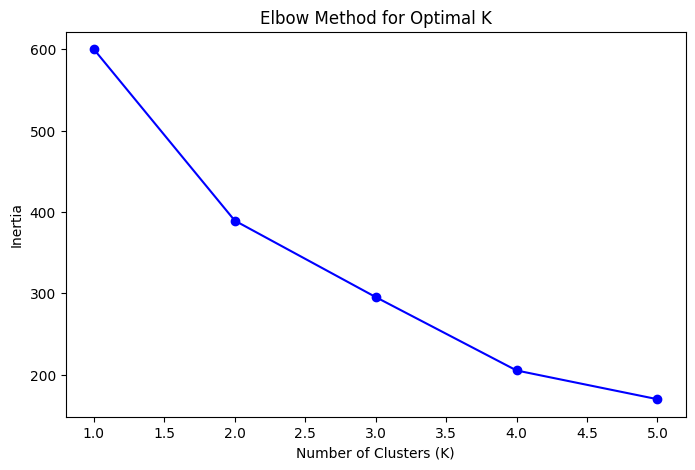

In [37]:
# Plot elbow curve
plt.figure(figsize=(8, 5))
plt.plot(K, segment_inertia, 'bo-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.savefig('elbow_plot.png')
plt.show()

In [38]:
# Apply K-Means with optimal K based on elbow method
optimal_k = 4

segment_kmeans = KMeans(n_clusters=optimal_k, random_state=42)

segment_df['cluster'] = segment_kmeans.fit_predict(X_segment_scaled)

In [39]:
# Analyze clusters
cluster_summary = (
    segment_df.groupby('cluster')[segment_features]
    .mean()
    .round(2)
)

print("Cluster Characteristics:")
print(cluster_summary)

Cluster Characteristics:
           Age  Annual Income (k$)  Spending Score (1-100)
cluster                                                   
0        53.98               47.71                   39.97
1        32.88               86.10                   81.53
2        25.44               40.00                   60.30
3        39.37               86.50                   19.58


Cluster 1 represents high-income, high-spending customers, while Cluster 3 represents high-income customers with relatively low spending. Cluster 2 contains younger customers with moderate income and relatively high spending, and Cluster 0 contains older customers with moderate income and lower spending.

In [40]:
# Targeted marketing strategies for each customer segment
for cluster in range(optimal_k):
    print(f"\nCluster {cluster} Strategy:")

    if cluster == 0:
        print("Older, moderate-spending customers: Offer loyalty rewards and personalized promotions.")
    elif cluster == 1:
        print("High-income, high-spending customers: Offer exclusive promotions and premium loyalty rewards.")
    elif cluster == 2:
        print("Young, active customers: Offer discounts, loyalty incentives, and engagement campaigns.")
    elif cluster == 3:
        print("High-income, low-spending customers: Use personalized offers to encourage more purchases.")


Cluster 0 Strategy:
Older, moderate-spending customers: Offer loyalty rewards and personalized promotions.

Cluster 1 Strategy:
High-income, high-spending customers: Offer exclusive promotions and premium loyalty rewards.

Cluster 2 Strategy:
Young, active customers: Offer discounts, loyalty incentives, and engagement campaigns.

Cluster 3 Strategy:
High-income, low-spending customers: Use personalized offers to encourage more purchases.


In [41]:
# Save cluster assignments to CSV
segment_df.to_csv('customer_segments.csv', index=False)

print("Customer segments saved to customer_segments.csv")

Customer segments saved to customer_segments.csv


The elbow curve shows that inertia decreases substantially from K=1 through K=4, while the improvement from K=4 to K=5 is much smaller. Therefore, K=4 was selected as a reasonable number of customer segments.